# 30 — Assembly101 three-seed, multi-strategy ensemble

This is the **last controlled improvement experiment**. It reuses the already trained
CE, learnable-text, and KD students from notebooks 19–23 and tests whether predictive
diversity across seeds/strategies improves the strong notebook-16 visual baseline.

Primary metric: **validation F1@50**. No model is trained and the test split is never
read. Candidate composition is selected on a deterministic 50% calibration subset and
evaluated once on the untouched 50% holdout subset.

The notebook deliberately stops if any reconstructed student does not reproduce the
corresponding notebook-23 validation metrics. This catches checkpoint, architecture,
normalization, and ordering errors before an ensemble result can be trusted.


## Protocol and decision rule

- Baseline: notebook-16 visual-only MS-TCN logits cached by notebook 28.
- Members: 3 seeds × {CE, learnable-text, KD} from notebook 23.
- Fixed ensemble rules: arithmetic probability mean, geometric probability mean, and
  majority vote. Anchored variants give the notebook-16 baseline a predeclared weight
  of 0.25, 0.50, or 0.75.
- Selection: calibration F1@50; F1@25, Edit, and smaller ensembles are tie-breakers
  inside a 0.05 F1@50 window.
- Promotion requires at least +0.30 F1@50 on calibration, holdout, and full validation,
  with no material F1@25/Edit regression.

## 1. Mount Google Drive


In [1]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


## 2. Imports, paths, and fixed configuration


In [2]:
from pathlib import Path
from datetime import datetime, timezone

import gc
import hashlib
import json
import math
import platform
import random
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 260)

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DRIVE_ROOT = Path("/content/drive/MyDrive/mmf_tas_lab_data")
FEATURE_ROOT = (
    DRIVE_ROOT / "text_assisted_tas" / "assembly101"
    / "coarse_mstcn_format" / "streaming_visual_features_v1"
)
DATA_ROOT_DRIVE = FEATURE_ROOT / "clip_vitb16"

SUMMARY_PATHS_DRIVE = {
    "notebook18": FEATURE_ROOT / "runs" / "18_text_assisted_concat_teachers" / "final_summary_full.json",
    "notebook19": FEATURE_ROOT / "runs" / "19_video_only_kd_students" / "full" / "final_summary.json",
    "notebook20": FEATURE_ROOT / "runs" / "20_learnable_text_students" / "full" / "final_summary.json",
    "notebook21": FEATURE_ROOT / "runs" / "21_text_student_kd_search" / "full" / "final_summary.json",
    "notebook23": FEATURE_ROOT / "runs" / "23_three_seed_repetition" / "full" / "final_summary.json",
}
NOTEBOOK28_CACHE_DRIVE = (
    FEATURE_ROOT / "runs" / "28_residual_pseudotext_logit_fusion"
    / "validation_logits_cache.npz"
)
DRIVE_OUT_ROOT = FEATURE_ROOT / "runs" / "30_three_seed_strategy_ensemble"

LOCAL_RUNTIME_ROOT = Path("/content/nb30_runtime")
LOCAL_INPUT_ROOT = LOCAL_RUNTIME_ROOT / "inputs"
LOCAL_CHECKPOINT_ROOT = LOCAL_INPUT_ROOT / "checkpoints"
LOCAL_FEATURE_ROOT = LOCAL_INPUT_ROOT / "validation_features"
LOCAL_MODEL_CACHE_ROOT = LOCAL_RUNTIME_ROOT / "model_logits_cache"
OUT_ROOT = LOCAL_RUNTIME_ROOT / "outputs"
ARTIFACT_ROOT = OUT_ROOT / "presentation_artifacts"
for path in [
    LOCAL_INPUT_ROOT, LOCAL_CHECKPOINT_ROOT, LOCAL_FEATURE_ROOT,
    LOCAL_MODEL_CACHE_ROOT, OUT_ROOT, ARTIFACT_ROOT,
]:
    path.mkdir(parents=True, exist_ok=True)

EXPECTED_VIDEO_DIM = 512
EXPECTED_TEMPORAL_LENGTH = 16
EXPECTED_NUM_CLASSES = 202
EXPECTED_TEXT_DIM = 512

NUM_STAGES = 4
NUM_LAYERS = 6
NUM_F_MAPS = 64
DROPOUT = 0.5
INITIAL_TEXT_TEMPERATURE = 0.07
LEARNABLE_RESIDUAL_SCALE = 0.10

BATCH_SIZE = 64
NUM_WORKERS = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FORCE_RECOMPUTE_LOGITS = False

BASELINE_EXPECTED_F1_50 = 18.97
BASELINE_TOLERANCE = 0.03
RECONSTRUCTION_TOLERANCE = 0.03
NEAR_BEST_CALIBRATION_F1 = 0.05
MIN_REQUIRED_F1_50_GAIN = 0.30
MAX_ALLOWED_F1_25_DROP = 0.25
MAX_ALLOWED_EDIT_DROP = 0.50

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Persistent output:", DRIVE_OUT_ROOT)
if not torch.cuda.is_available():
    print("WARNING: CPU is supported, but a Colab T4 is recommended for faster inference.")


Python: 3.12.13
PyTorch: 2.11.0+cpu
Device: cpu
GPU: CPU
Persistent output: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/30_three_seed_strategy_ensemble


## 3. Robust Drive I/O and local staging


In [3]:
def remount_google_drive():
    print("Google Drive connection was lost. Remounting...")
    try:
        drive.flush_and_unmount()
    except Exception:
        pass
    time.sleep(2)
    drive.mount("/content/drive", force_remount=True)


def read_nonempty_lines(path, max_attempts=5):
    path = Path(path)
    for attempt in range(1, max_attempts + 1):
        try:
            return [
                line.strip()
                for line in path.read_text(
                    encoding="utf-8", errors="replace"
                ).splitlines()
                if line.strip()
            ]
        except OSError as error:
            if attempt == max_attempts:
                raise
            if error.errno == 107:
                remount_google_drive()
            else:
                time.sleep(2 * attempt)


def copy_with_retry(source, destination, max_attempts=5, overwrite=False):
    source = Path(source)
    destination = Path(destination)
    temporary = destination.with_name(destination.name + ".part")
    for attempt in range(1, max_attempts + 1):
        try:
            destination.parent.mkdir(parents=True, exist_ok=True)
            if not overwrite and destination.exists() and destination.stat().st_size > 0:
                return destination
            if temporary.exists():
                temporary.unlink()
            expected_size = source.stat().st_size
            shutil.copyfile(source, temporary)
            if temporary.stat().st_size != expected_size:
                raise OSError(f"Incomplete copy: {source}")
            temporary.replace(destination)
            return destination
        except OSError as error:
            try:
                if temporary.exists():
                    temporary.unlink()
            except OSError:
                pass
            if attempt == max_attempts:
                raise
            if error.errno == 107:
                remount_google_drive()
            else:
                time.sleep(2 * attempt)


def drive_file_available(path, max_attempts=3):
    path = Path(path)
    for attempt in range(1, max_attempts + 1):
        try:
            return path.exists() and path.stat().st_size > 0
        except OSError as error:
            if attempt == max_attempts:
                return False
            if error.errno == 107:
                remount_google_drive()
            else:
                time.sleep(2 * attempt)
    return False


def resolve_bundle(split_dir, split_name):
    split_dir = Path(split_dir)
    for candidate in [
        split_dir / f"{split_name}.bundle",
        split_dir / f"{split_name}.split1.bundle",
    ]:
        if candidate.exists():
            return candidate
    candidates = sorted(
        path for path in split_dir.glob("*.bundle")
        if split_name.lower() in path.name.lower()
        and ".partial." not in path.name.lower()
    )
    if len(candidates) != 1:
        raise FileNotFoundError(
            f"Could not uniquely resolve {split_name} bundle: {candidates}"
        )
    return candidates[0]


def nested_value(mapping, *paths):
    for path in paths:
        value = mapping
        try:
            for key in path:
                value = value[key]
        except (KeyError, TypeError):
            continue
        if value not in {None, ""}:
            return value
    return None


# Stage the five small summaries first so all downstream paths are resolved locally.
local_summary_paths = {}
for name, drive_path in tqdm(SUMMARY_PATHS_DRIVE.items(), desc="Stage summaries"):
    local_path = LOCAL_INPUT_ROOT / f"{name}_final_summary.json"
    copy_with_retry(drive_path, local_path)
    local_summary_paths[name] = local_path

summaries = {
    name: json.loads(path.read_text(encoding="utf-8"))
    for name, path in local_summary_paths.items()
}
for name, summary in summaries.items():
    if summary.get("status") != "completed":
        raise RuntimeError(f"{name} is not marked completed.")

n18 = summaries["notebook18"]
n19 = summaries["notebook19"]
n20 = summaries["notebook20"]
n21 = summaries["notebook21"]
n23 = summaries["notebook23"]

teacher_experiment = n18["experiments"]["mstcn/clip_vitb16"]
TRAIN_MEAN_DRIVE = Path(teacher_experiment["paths"]["train_video_mean"])
TRAIN_STD_DRIVE = Path(teacher_experiment["paths"]["train_video_std"])

ce7 = n19["controlled_ce"]
text7 = n20["selected_text_strategy"]
kd7 = n21["selected_kd_configuration"]

seed7_sources = {
    "s7_ce": nested_value(
        ce7, ("test", "checkpoint"), ("paths", "best_student"), ("best_student",)
    ),
    "s7_text": nested_value(
        text7, ("checkpoint",), ("test", "checkpoint"), ("paths", "best_student"),
        ("best_student",)
    ),
    "s7_kd": nested_value(
        kd7, ("checkpoint",), ("paths", "best_student"), ("best_student",)
    ),
}

# Explicit fallbacks match the completed notebook layouts and are used only if an
# older summary omitted the checkpoint field.
fallback_seed7 = {
    "s7_ce": FEATURE_ROOT / "runs" / "19_video_only_kd_students" / "full"
             / "controlled_ce" / "models" / "best_student.pt",
    "s7_text": FEATURE_ROOT / "runs" / "20_learnable_text_students" / "full"
               / "learnable_clip_beta_0p01" / "models" / "best_student.pt",
    "s7_kd": FEATURE_ROOT / "runs" / "21_text_student_kd_search" / "full" / "kd_only"
             / "kd_lambda_0p2_temperature_4_policy_all" / "models" / "best_student.pt",
}
for key, value in list(seed7_sources.items()):
    seed7_sources[key] = Path(value) if value is not None else fallback_seed7[key]

checkpoint_sources = dict(seed7_sources)
for seed in [17, 42]:
    for strategy in ["ce", "text", "kd"]:
        checkpoint_sources[f"s{seed}_{strategy}"] = (
            FEATURE_ROOT / "runs" / "23_three_seed_repetition" / "full"
            / f"seed_{seed}" / strategy / "models" / "best_student.pt"
        )

VAL_BUNDLE_DRIVE = resolve_bundle(DATA_ROOT_DRIVE / "splits", "val")
val_ids = [Path(line).stem for line in read_nonempty_lines(VAL_BUNDLE_DRIVE)]
if len(val_ids) == 0 or len(val_ids) != len(set(val_ids)):
    raise RuntimeError("Invalid validation bundle.")

LOCAL_MAPPING = LOCAL_INPUT_ROOT / "mapping.txt"
LOCAL_N28_CACHE = LOCAL_INPUT_ROOT / "notebook28_validation_logits_cache.npz"
LOCAL_TRAIN_MEAN = LOCAL_INPUT_ROOT / "train_video_mean.npy"
LOCAL_TRAIN_STD = LOCAL_INPUT_ROOT / "train_video_std.npy"

staging_jobs = [
    (DATA_ROOT_DRIVE / "mapping.txt", LOCAL_MAPPING),
    (NOTEBOOK28_CACHE_DRIVE, LOCAL_N28_CACHE),
    (TRAIN_MEAN_DRIVE, LOCAL_TRAIN_MEAN),
    (TRAIN_STD_DRIVE, LOCAL_TRAIN_STD),
]
for sequence_id in val_ids:
    staging_jobs.append((
        DATA_ROOT_DRIVE / "features" / f"{sequence_id}.npy",
        LOCAL_FEATURE_ROOT / f"{sequence_id}.npy",
    ))

for source, destination in tqdm(staging_jobs, desc="Stage validation inputs"):
    copy_with_retry(source, destination)

local_checkpoint_paths = {}
for key, source in tqdm(checkpoint_sources.items(), desc="Stage 9 checkpoints"):
    destination = LOCAL_CHECKPOINT_ROOT / f"{key}.pt"
    copy_with_retry(source, destination)
    local_checkpoint_paths[key] = destination

print("Validation sequences:", len(val_ids))
print("Staged checkpoints:", len(local_checkpoint_paths))
print(json.dumps({key: str(value) for key, value in checkpoint_sources.items()}, indent=2))


Stage summaries:   0%|          | 0/5 [00:00<?, ?it/s]

Stage validation inputs:   0%|          | 0/124 [00:00<?, ?it/s]

Stage 9 checkpoints:   0%|          | 0/9 [00:00<?, ?it/s]

Validation sequences: 120
Staged checkpoints: 9
{
  "s7_ce": "/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/19_video_only_kd_students/full/controlled_ce/models/best_student.pt",
  "s7_text": "/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/learnable_clip_beta_0p01/models/best_student.pt",
  "s7_kd": "/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/kd_only/kd_lambda_0p2_temperature_4_policy_all/models/best_student.pt",
  "s17_ce": "/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/23_three_seed_repetition/full/seed_17/ce/models/best_student.pt",
  "s17_text": "/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly1

## 4. Load and audit the validation inputs


In [4]:
def load_mapping(path):
    id_to_label = {}
    label_to_id = {}
    for line in read_nonempty_lines(path):
        class_id_text, label = line.split(maxsplit=1)
        class_id = int(class_id_text)
        if class_id in id_to_label or label in label_to_id:
            raise ValueError(f"Duplicate mapping entry: {line}")
        id_to_label[class_id] = label
        label_to_id[label] = class_id
    return id_to_label, label_to_id


id_to_label, label_to_id = load_mapping(LOCAL_MAPPING)
num_classes = len(id_to_label)
if num_classes != EXPECTED_NUM_CLASSES or set(id_to_label) != set(range(num_classes)):
    raise ValueError(f"Expected contiguous class IDs 0..201, found {num_classes} classes.")

IGNORE_CLASS_NAMES = {"background", "SIL", "silence"}
ignore_class_ids = {
    label_to_id[name] for name in IGNORE_CLASS_NAMES if name in label_to_id
}

with np.load(LOCAL_N28_CACHE, allow_pickle=False) as cache:
    required_cache_keys = {"sequence_ids", "targets", "visual_logits"}
    if not required_cache_keys.issubset(set(cache.files)):
        raise KeyError(f"Notebook-28 cache lacks {required_cache_keys - set(cache.files)}")
    cached_sequence_ids = cache["sequence_ids"].astype(str).tolist()
    targets_array = cache["targets"].astype(np.int64)
    n16_visual_logits = cache["visual_logits"].astype(np.float32)

expected_logit_shape = (
    len(val_ids), EXPECTED_TEMPORAL_LENGTH, EXPECTED_NUM_CLASSES
)
if cached_sequence_ids != val_ids:
    raise RuntimeError("Notebook-28 cache order does not match the official val bundle.")
if targets_array.shape != (len(val_ids), EXPECTED_TEMPORAL_LENGTH):
    raise ValueError(f"Unexpected target shape: {targets_array.shape}")
if n16_visual_logits.shape != expected_logit_shape:
    raise ValueError(f"Unexpected notebook-16 logit shape: {n16_visual_logits.shape}")
if not np.isfinite(n16_visual_logits).all():
    raise ValueError("Notebook-16 logits contain non-finite values.")

train_video_mean = np.load(LOCAL_TRAIN_MEAN).astype(np.float32)
train_video_std = np.load(LOCAL_TRAIN_STD).astype(np.float32)
if train_video_mean.shape != (EXPECTED_VIDEO_DIM,):
    raise ValueError(f"Unexpected train mean shape: {train_video_mean.shape}")
if train_video_std.shape != (EXPECTED_VIDEO_DIM,) or np.any(train_video_std <= 0):
    raise ValueError(f"Invalid train std shape/values: {train_video_std.shape}")


class ValidationVideoDataset(Dataset):
    def __init__(self, sequence_ids):
        self.sequence_ids = list(sequence_ids)

    def __len__(self):
        return len(self.sequence_ids)

    def __getitem__(self, index):
        sequence_id = self.sequence_ids[index]
        video = np.load(LOCAL_FEATURE_ROOT / f"{sequence_id}.npy").astype(np.float32)
        if video.shape != (EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH):
            raise ValueError(f"Unexpected feature shape for {sequence_id}: {video.shape}")
        if not np.isfinite(video).all():
            raise ValueError(f"Non-finite feature values for {sequence_id}")
        video = (video - train_video_mean[:, None]) / (train_video_std[:, None] + 1e-8)
        return {
            "sequence_id": sequence_id,
            "video": torch.from_numpy(video),
        }


val_dataset = ValidationVideoDataset(val_ids)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
sample = next(iter(val_loader))
assert sample["video"].shape[1:] == (
    EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH
)
print("Classes:", num_classes)
print("Ignored class IDs:", ignore_class_ids)
print("Validation logit shape:", expected_logit_shape)
print("Video batch:", tuple(sample["video"].shape))


Classes: 202
Ignored class IDs: set()
Validation logit shape: (120, 16, 202)
Video batch: (64, 512, 16)


## 5. Exact temporal action segmentation metrics


In [5]:
def collapse_segments(frame_labels, ignored_ids=None):
    ignored_ids = set(ignored_ids or [])
    labels, starts, ends = [], [], []
    active = None
    for index, label in enumerate(frame_labels):
        label = int(label)
        if label in ignored_ids:
            if active is not None:
                ends.append(index)
                active = None
            continue
        if label != active:
            if active is not None:
                ends.append(index)
            labels.append(label)
            starts.append(index)
            active = label
    if active is not None:
        ends.append(len(frame_labels))
    return labels, starts, ends


def levenshtein_distance(predicted, target):
    distance = np.zeros((len(predicted) + 1, len(target) + 1), dtype=np.int32)
    distance[:, 0] = np.arange(len(predicted) + 1)
    distance[0, :] = np.arange(len(target) + 1)
    for row in range(1, len(predicted) + 1):
        for column in range(1, len(target) + 1):
            substitution = int(predicted[row - 1] != target[column - 1])
            distance[row, column] = min(
                distance[row - 1, column] + 1,
                distance[row, column - 1] + 1,
                distance[row - 1, column - 1] + substitution,
            )
    return int(distance[-1, -1])


def edit_score_single(prediction, target, ignored_ids=None):
    predicted_segments, _, _ = collapse_segments(prediction, ignored_ids)
    target_segments, _, _ = collapse_segments(target, ignored_ids)
    if not predicted_segments and not target_segments:
        return 100.0
    denominator = max(len(predicted_segments), len(target_segments))
    if denominator == 0:
        return 0.0
    distance = levenshtein_distance(predicted_segments, target_segments)
    return (1.0 - distance / denominator) * 100.0


def f_score_single(prediction, target, overlap, ignored_ids=None):
    predicted_labels, predicted_starts, predicted_ends = collapse_segments(
        prediction, ignored_ids
    )
    target_labels, target_starts, target_ends = collapse_segments(target, ignored_ids)
    true_positives = 0
    false_positives = 0
    hits = np.zeros(len(target_labels), dtype=np.float32)
    for predicted_index in range(len(predicted_labels)):
        best_iou = 0.0
        best_target = -1
        for target_index in range(len(target_labels)):
            if predicted_labels[predicted_index] != target_labels[target_index]:
                continue
            intersection = (
                min(predicted_ends[predicted_index], target_ends[target_index])
                - max(predicted_starts[predicted_index], target_starts[target_index])
            )
            union = (
                max(predicted_ends[predicted_index], target_ends[target_index])
                - min(predicted_starts[predicted_index], target_starts[target_index])
            )
            iou = max(intersection, 0) / union if union > 0 else 0.0
            if iou > best_iou:
                best_iou = iou
                best_target = target_index
        if best_iou >= overlap and best_target >= 0 and hits[best_target] == 0:
            true_positives += 1
            hits[best_target] = 1
        else:
            false_positives += 1
    false_negatives = len(target_labels) - int(hits.sum())
    return true_positives, false_positives, false_negatives


def compute_metrics(predictions, targets, ignored_ids=None):
    total_correct = 0
    total_positions = 0
    edit_scores = []
    f_statistics = {0.10: [0, 0, 0], 0.25: [0, 0, 0], 0.50: [0, 0, 0]}
    for sequence_id, prediction in predictions.items():
        target = targets[sequence_id]
        total_correct += int((prediction == target).sum())
        total_positions += len(target)
        edit_scores.append(edit_score_single(prediction, target, ignored_ids))
        for overlap in f_statistics:
            tp, fp, fn = f_score_single(prediction, target, overlap, ignored_ids)
            f_statistics[overlap][0] += tp
            f_statistics[overlap][1] += fp
            f_statistics[overlap][2] += fn
    metrics = {
        "acc": 100.0 * total_correct / max(total_positions, 1),
        "edit": float(np.mean(edit_scores)) if edit_scores else 0.0,
    }
    for overlap, (tp, fp, fn) in f_statistics.items():
        precision = tp / max(tp + fp, 1e-8)
        recall = tp / max(tp + fn, 1e-8)
        f1 = 2.0 * precision * recall / max(precision + recall, 1e-8)
        metrics[f"f1@{int(overlap * 100)}"] = 100.0 * f1
    return metrics


def metrics_for_array(prediction_array, indices):
    indices = np.asarray(indices, dtype=np.int64)
    predictions = {
        val_ids[index]: prediction_array[index] for index in indices
    }
    targets = {
        val_ids[index]: targets_array[index] for index in indices
    }
    return compute_metrics(predictions, targets, ignore_class_ids)


def round_metrics(metrics):
    return {key: round(float(value), 2) for key, value in metrics.items()}


print("Metric implementation ready.")


Metric implementation ready.


## 6. Exact student architectures from notebook 23


In [6]:
class DilatedResidualLayer(nn.Module):
    def __init__(self, dilation, channels, dropout):
        super().__init__()
        self.conv_dilated = nn.Conv1d(
            channels, channels, kernel_size=3, padding=dilation, dilation=dilation
        )
        self.conv_1x1 = nn.Conv1d(channels, channels, kernel_size=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs):
        output = F.relu(self.conv_dilated(inputs))
        output = self.conv_1x1(output)
        output = self.dropout(output)
        return inputs + output


class SingleStage(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.input_projection = nn.Conv1d(input_dim, NUM_F_MAPS, kernel_size=1)
        self.layers = nn.ModuleList([
            DilatedResidualLayer(
                dilation=2 ** layer_index,
                channels=NUM_F_MAPS,
                dropout=DROPOUT,
            )
            for layer_index in range(NUM_LAYERS)
        ])
        self.output_projection = nn.Conv1d(NUM_F_MAPS, num_classes, kernel_size=1)

    def forward(self, inputs, return_hidden=False):
        hidden = self.input_projection(inputs)
        for layer in self.layers:
            hidden = layer(hidden)
        logits = self.output_projection(hidden)
        if return_hidden:
            return logits, hidden
        return logits


class MSTCNVideoStudent(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stage1 = SingleStage(EXPECTED_VIDEO_DIM, num_classes)
        self.refinement_stages = nn.ModuleList([
            SingleStage(num_classes, num_classes)
            for _ in range(NUM_STAGES - 1)
        ])

    def forward(self, video):
        logits = self.stage1(video)
        outputs = [logits]
        for stage in self.refinement_stages:
            logits = stage(F.softmax(logits, dim=1))
            outputs.append(logits)
        return torch.stack(outputs, dim=0)


class MSTCNTextEmbeddingStudent(nn.Module):
    def __init__(self, num_classes, clip_text_bank, prototype_mode="learnable"):
        super().__init__()
        if prototype_mode not in {"fixed", "learnable"}:
            raise ValueError(f"Unknown prototype mode: {prototype_mode}")
        self.prototype_mode = prototype_mode
        self.stage1 = SingleStage(EXPECTED_VIDEO_DIM, num_classes)
        self.refinement_stages = nn.ModuleList([
            SingleStage(num_classes, num_classes)
            for _ in range(NUM_STAGES - 1)
        ])
        self.video_to_text = nn.Conv1d(NUM_F_MAPS, EXPECTED_TEXT_DIM, kernel_size=1)
        self.register_buffer(
            "clip_text_bank", F.normalize(clip_text_bank.float().clone(), dim=-1)
        )
        self.prototype_delta = nn.Parameter(
            torch.zeros_like(self.clip_text_bank),
            requires_grad=(prototype_mode == "learnable"),
        )
        self.logit_scale = nn.Parameter(
            torch.tensor(math.log(1.0 / INITIAL_TEXT_TEMPERATURE))
        )

    def adapted_prototypes(self):
        prototypes = self.clip_text_bank + LEARNABLE_RESIDUAL_SCALE * self.prototype_delta
        return F.normalize(prototypes, dim=-1)

    def forward(self, video, return_text_aux=False):
        logits, hidden = self.stage1(video, return_hidden=True)
        outputs = [logits]
        for stage in self.refinement_stages:
            logits = stage(F.softmax(logits, dim=1))
            outputs.append(logits)
        stacked_outputs = torch.stack(outputs, dim=0)
        if not return_text_aux:
            return stacked_outputs
        auxiliary = {
            "projected_video": F.normalize(self.video_to_text(hidden), dim=1),
            "prototypes": self.adapted_prototypes(),
            "logit_scale": self.logit_scale.exp().clamp(max=100.0),
        }
        return stacked_outputs, auxiliary


def load_checkpoint(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def create_student(model_key):
    strategy = model_key.split("_", 1)[1]
    if strategy == "text":
        zero_text_bank = torch.zeros(EXPECTED_NUM_CLASSES, EXPECTED_TEXT_DIM)
        return MSTCNTextEmbeddingStudent(
            EXPECTED_NUM_CLASSES, zero_text_bank, prototype_mode="learnable"
        )
    return MSTCNVideoStudent(EXPECTED_NUM_CLASSES)


with torch.no_grad():
    dummy = torch.zeros(2, EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH)
    assert create_student("s7_ce")(dummy).shape == (
        NUM_STAGES, 2, EXPECTED_NUM_CLASSES, EXPECTED_TEMPORAL_LENGTH
    )
    assert create_student("s7_text")(dummy).shape == (
        NUM_STAGES, 2, EXPECTED_NUM_CLASSES, EXPECTED_TEMPORAL_LENGTH
    )
del dummy
print("Student architectures reconstructed exactly.")


Student architectures reconstructed exactly.


## 7. Resumable inference for all nine students


In [7]:
MODEL_KEYS = [
    f"s{seed}_{strategy}"
    for seed in [7, 17, 42]
    for strategy in ["ce", "text", "kd"]
]


def validate_model_cache(path):
    try:
        with np.load(path, allow_pickle=False) as cache:
            if {"sequence_ids", "logits"} - set(cache.files):
                return None
            if cache["sequence_ids"].astype(str).tolist() != val_ids:
                return None
            logits = cache["logits"].astype(np.float32)
        if logits.shape != expected_logit_shape or not np.isfinite(logits).all():
            return None
        return logits
    except Exception:
        return None


@torch.no_grad()
def compute_student_logits(model_key):
    model = create_student(model_key).to(DEVICE)
    checkpoint = load_checkpoint(local_checkpoint_paths[model_key])
    state_dict = checkpoint.get(
        "model_state_dict", checkpoint.get("state_dict", checkpoint)
    )
    model.load_state_dict(state_dict, strict=True)
    model.eval()

    batches = []
    observed_ids = []
    for batch in tqdm(val_loader, desc=f"Inference {model_key}"):
        video = batch["video"].to(DEVICE, non_blocking=True)
        final_logits = model(video)[-1].permute(0, 2, 1)
        batches.append(final_logits.float().cpu().numpy())
        observed_ids.extend(list(batch["sequence_id"]))

    logits = np.concatenate(batches, axis=0).astype(np.float32)
    if observed_ids != val_ids:
        raise RuntimeError(f"DataLoader order changed for {model_key}.")
    if logits.shape != expected_logit_shape or not np.isfinite(logits).all():
        raise RuntimeError(f"Invalid logits for {model_key}: {logits.shape}")

    del model, checkpoint, state_dict, batches
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return logits


student_logits = {}
for model_key in MODEL_KEYS:
    local_cache_path = LOCAL_MODEL_CACHE_ROOT / f"{model_key}_validation_logits.npz"
    drive_cache_path = DRIVE_OUT_ROOT / "model_logits_cache" / local_cache_path.name
    logits = None

    if not FORCE_RECOMPUTE_LOGITS and local_cache_path.exists():
        logits = validate_model_cache(local_cache_path)
        if logits is not None:
            print("Loaded local cache:", model_key)

    if logits is None and not FORCE_RECOMPUTE_LOGITS and drive_file_available(drive_cache_path):
        copy_with_retry(drive_cache_path, local_cache_path, overwrite=True)
        logits = validate_model_cache(local_cache_path)
        if logits is not None:
            print("Loaded Drive cache:", model_key)

    if logits is None:
        logits = compute_student_logits(model_key)
        np.savez_compressed(
            local_cache_path,
            sequence_ids=np.asarray(val_ids, dtype="U"),
            logits=logits,
        )
        copy_with_retry(local_cache_path, drive_cache_path, overwrite=True)
        print("Computed and cached:", model_key)

    student_logits[model_key] = logits

CONSOLIDATED_CACHE = OUT_ROOT / "validation_student_logits.npz"
np.savez_compressed(
    CONSOLIDATED_CACHE,
    sequence_ids=np.asarray(val_ids, dtype="U"),
    targets=targets_array,
    n16_visual_logits=n16_visual_logits,
    **student_logits,
)
print("All student logits ready:", len(student_logits))
print("Saved consolidated cache:", CONSOLIDATED_CACHE)


Inference s7_ce:   0%|          | 0/2 [00:00<?, ?it/s]

Computed and cached: s7_ce


Inference s7_text:   0%|          | 0/2 [00:00<?, ?it/s]

Computed and cached: s7_text


Inference s7_kd:   0%|          | 0/2 [00:00<?, ?it/s]

...

Computed and cached: s42_ce


Inference s42_text:   0%|          | 0/2 [00:00<?, ?it/s]

Computed and cached: s42_text


Inference s42_kd:   0%|          | 0/2 [00:00<?, ?it/s]

Computed and cached: s42_kd
All student logits ready: 9
Saved consolidated cache: /content/nb30_runtime/outputs/validation_student_logits.npz


## 8. Mandatory reconstruction audit against notebook 23


In [8]:
full_indices = np.arange(len(val_ids), dtype=np.int64)
n23_expected_df = pd.DataFrame(n23["per_seed_results"])
metric_names = ["acc", "edit", "f1@10", "f1@25", "f1@50"]

audit_rows = []
for model_key in MODEL_KEYS:
    seed_text, strategy = model_key.split("_", 1)
    seed = int(seed_text[1:])
    metrics = metrics_for_array(student_logits[model_key].argmax(axis=-1), full_indices)
    expected_rows = n23_expected_df[
        (n23_expected_df["seed"].astype(int) == seed)
        & (n23_expected_df["strategy"].astype(str) == strategy)
    ]
    if len(expected_rows) != 1:
        raise RuntimeError(f"Notebook-23 expected row not unique for {model_key}.")
    expected = expected_rows.iloc[0]
    errors = {
        metric: abs(float(metrics[metric]) - float(expected[f"val_{metric}"]))
        for metric in metric_names
    }
    audit_rows.append({
        "model_key": model_key,
        "seed": seed,
        "strategy": strategy,
        **{metric: float(metrics[metric]) for metric in metric_names},
        **{f"expected_{metric}": float(expected[f"val_{metric}"]) for metric in metric_names},
        "max_absolute_error": max(errors.values()),
        "reconstruction_pass": max(errors.values()) <= RECONSTRUCTION_TOLERANCE,
    })

individual_audit_df = pd.DataFrame(audit_rows)
INDIVIDUAL_AUDIT_CSV = OUT_ROOT / "individual_model_validation_audit.csv"
individual_audit_df.to_csv(INDIVIDUAL_AUDIT_CSV, index=False)
display(individual_audit_df.round(3))

failed_audits = individual_audit_df[~individual_audit_df["reconstruction_pass"]]
if len(failed_audits):
    raise RuntimeError(
        "Student reconstruction audit failed. Do not trust an ensemble until the "
        f"mismatch is fixed:\n{failed_audits.to_string(index=False)}"
    )

baseline_full_metrics = metrics_for_array(
    n16_visual_logits.argmax(axis=-1), full_indices
)
if abs(baseline_full_metrics["f1@50"] - BASELINE_EXPECTED_F1_50) > BASELINE_TOLERANCE:
    raise RuntimeError(
        "Notebook-16 baseline audit failed: "
        f"{baseline_full_metrics['f1@50']:.4f} != {BASELINE_EXPECTED_F1_50:.2f}"
    )

print("All 9 student checkpoints reproduce notebook 23 within tolerance.")
print("Notebook-16 baseline:", round_metrics(baseline_full_metrics))


,model_key,seed,strategy,acc,edit,f1@10,f1@25,f1@50,expected_acc,expected_edit,expected_f1@10,expected_f1@25,expected_f1@50,max_absolute_error,reconstruction_pass
0,s7_ce,7,ce,30.000,26.173,29.140,24.775,18.357,30.00,26.17,29.14,24.78,18.36,0.005,True
1,s7_text,7,text,30.521,26.527,29.246,25.798,19.029,30.52,26.53,29.25,25.80,19.03,0.004,True
2,s7_kd,7,kd,30.417,26.364,29.597,25.945,19.270,30.42,26.36,29.60,25.94,19.27,0.005,True
3,s17_ce,17,ce,28.646,25.473,28.861,24.304,17.215,28.65,25.47,28.86,24.30,17.22,0.005,True
4,s17_text,17,text,28.646,25.917,28.446,24.060,17.419,28.65,25.92,28.45,24.06,17.42,0.004,True
5,s17_kd,17,kd,28.802,25.549,28.661,24.406,17.272,28.80,25.55,28.66,24.41,17.27,0.004,True
6,s42_ce,42,ce,29.219,25.057,28.427,24.889,18.067,29.22,25.06,28.43,24.89,18.07,0.003,True
7,s42_text,42,text,29.115,25.550,28.987,25.190,17.722,29.11,25.55,28.99,25.19,17.72,0.005,True
8,s42_kd,42,kd,29.167,25.945,28.590,25.286,17.662,29.17,25.95,28.59,25.29,17.66,0.005,True


All 9 student checkpoints reproduce notebook 23 within tolerance.
Notebook-16 baseline: {'acc': 29.95, 'edit': 26.01, 'f1@10': 29.23, 'f1@25': 25.9, 'f1@50': 18.97}


## 9. Deterministic calibration/holdout split and fixed ensembles


In [9]:
hashed_ids = sorted(
    val_ids,
    key=lambda sequence_id: hashlib.sha256(
        f"notebook28:{SEED}:{sequence_id}".encode("utf-8")
    ).hexdigest(),
)
calibration_ids = set(hashed_ids[: len(hashed_ids) // 2])
holdout_ids = set(hashed_ids[len(hashed_ids) // 2 :])
calibration_indices = np.asarray([
    index for index, sequence_id in enumerate(val_ids)
    if sequence_id in calibration_ids
], dtype=np.int64)
holdout_indices = np.asarray([
    index for index, sequence_id in enumerate(val_ids)
    if sequence_id in holdout_ids
], dtype=np.int64)
assert len(calibration_indices) + len(holdout_indices) == len(val_ids)
assert not (calibration_ids & holdout_ids)


def softmax_numpy(logits):
    shifted = logits - logits.max(axis=-1, keepdims=True)
    exponentiated = np.exp(shifted)
    return exponentiated / np.maximum(
        exponentiated.sum(axis=-1, keepdims=True), 1e-12
    )


logit_bank = {"n16": n16_visual_logits, **student_logits}
probability_bank = {
    key: softmax_numpy(logits).astype(np.float32)
    for key, logits in logit_bank.items()
}


def ensemble_weights(member_keys, anchor_weight=None):
    member_keys = list(member_keys)
    if "n16" not in member_keys:
        return np.full(len(member_keys), 1.0 / len(member_keys), dtype=np.float64)
    if anchor_weight is None:
        anchor_weight = 1.0 / len(member_keys)
    anchor_weight = float(anchor_weight)
    if not 0.0 < anchor_weight < 1.0:
        raise ValueError(f"Invalid anchor weight: {anchor_weight}")
    non_anchor_count = len(member_keys) - 1
    weights = np.asarray([
        anchor_weight if key == "n16" else (1.0 - anchor_weight) / non_anchor_count
        for key in member_keys
    ], dtype=np.float64)
    return weights


def ensemble_predict(member_keys, method, anchor_weight=None):
    member_keys = list(member_keys)
    weights = ensemble_weights(member_keys, anchor_weight)
    if method == "mean_probability":
        score = sum(
            weight * probability_bank[key]
            for key, weight in zip(member_keys, weights)
        )
    elif method == "mean_log_probability":
        score = sum(
            weight * np.log(np.maximum(probability_bank[key], 1e-12))
            for key, weight in zip(member_keys, weights)
        )
    elif method == "majority_vote":
        if anchor_weight is not None:
            raise ValueError("Weighted majority vote is intentionally not searched.")
        shape = probability_bank[member_keys[0]].shape
        score = np.zeros(shape, dtype=np.float32)
        row_index = np.arange(shape[0])[:, None]
        time_index = np.arange(shape[1])[None, :]
        for key, weight in zip(member_keys, weights):
            labels = probability_bank[key].argmax(axis=-1)
            score[row_index, time_index, labels] += float(weight)
        mean_probability = sum(probability_bank[key] for key in member_keys) / len(member_keys)
        score += 1e-6 * mean_probability
    else:
        raise ValueError(f"Unknown ensemble method: {method}")
    return score.argmax(axis=-1).astype(np.int64)


student_groups = {
    "seed7_text_only": ["s7_text"],
    "seed7_kd_only": ["s7_kd"],
    "seed7_text_kd": ["s7_text", "s7_kd"],
    "seed7_all": ["s7_ce", "s7_text", "s7_kd"],
    "ce_3seed": ["s7_ce", "s17_ce", "s42_ce"],
    "text_3seed": ["s7_text", "s17_text", "s42_text"],
    "kd_3seed": ["s7_kd", "s17_kd", "s42_kd"],
    "all_9_students": MODEL_KEYS,
}

candidate_configs = []
for group_name, members in student_groups.items():
    methods = ["mean_probability"] if len(members) == 1 else [
        "mean_probability", "mean_log_probability", "majority_vote"
    ]
    for method in methods:
        candidate_configs.append({
            "config_id": f"{group_name}__{method}",
            "group": group_name,
            "member_keys": list(members),
            "method": method,
            "anchor_weight": None,
        })
    for anchor_weight in [0.25, 0.50, 0.75]:
        for method in ["mean_probability", "mean_log_probability"]:
            candidate_configs.append({
                "config_id": f"n16_{anchor_weight:.2f}__{group_name}__{method}",
                "group": f"n16_plus_{group_name}",
                "member_keys": ["n16", *members],
                "method": method,
                "anchor_weight": anchor_weight,
            })

print("Calibration sequences:", len(calibration_indices))
print("Holdout sequences:", len(holdout_indices))
print("Predeclared ensemble candidates:", len(candidate_configs))


Calibration sequences: 60
Holdout sequences: 60
Predeclared ensemble candidates: 68


## 10. Select one configuration on calibration only


In [10]:
search_rows = []
for config in tqdm(candidate_configs, desc="Calibration-only ensemble search"):
    predictions = ensemble_predict(
        config["member_keys"], config["method"], config["anchor_weight"]
    )
    metrics = metrics_for_array(predictions, calibration_indices)
    search_rows.append({
        "config_id": config["config_id"],
        "group": config["group"],
        "members": "|".join(config["member_keys"]),
        "n_members": len(config["member_keys"]),
        "method": config["method"],
        "anchor_weight": config["anchor_weight"],
        **metrics,
    })

search_df = pd.DataFrame(search_rows)
best_calibration_f1 = float(search_df["f1@50"].max())
near_best_df = search_df[
    search_df["f1@50"] >= best_calibration_f1 - NEAR_BEST_CALIBRATION_F1
].copy()
selected_row = (
    near_best_df.sort_values(
        ["f1@25", "edit", "f1@50", "n_members", "config_id"],
        ascending=[False, False, False, True, True],
    ).iloc[0]
)
selected_config = next(
    config for config in candidate_configs
    if config["config_id"] == selected_row["config_id"]
)

SEARCH_CSV = OUT_ROOT / "calibration_ensemble_search.csv"
search_df.sort_values(
    ["f1@50", "f1@25", "edit"], ascending=False
).to_csv(SEARCH_CSV, index=False)

display(
    search_df.sort_values(
        ["f1@50", "f1@25", "edit"], ascending=False
    ).head(20).round(3)
)
print("Selected using calibration only:")
print(json.dumps(selected_config, indent=2))
print("Holdout metrics have not been computed or inspected in this search.")


Calibration-only ensemble search:   0%|          | 0/68 [00:00<?, ?it/s]

,config_id,group,members,n_members,method,anchor_weight,acc,edit,f1@10,f1@25,f1@50
9,n16_0.25__seed7_kd_only__mean_log_probability,n16_plus_seed7_kd_only,n16|s7_kd,2,mean_log_probability,0.25,27.917,24.829,26.829,23.415,16.829
8,n16_0.25__seed7_kd_only__mean_probability,n16_plus_seed7_kd_only,n16|s7_kd,2,mean_probability,0.25,27.708,24.677,26.585,23.171,16.829
11,n16_0.50__seed7_kd_only__mean_log_probability,n16_plus_seed7_kd_only,n16|s7_kd,2,mean_log_probability,0.50,27.812,24.734,26.471,22.794,16.667
17,n16_0.25__seed7_text_kd__mean_probability,n16_plus_seed7_text_kd,n16|s7_text|s7_kd,3,mean_probability,0.25,27.812,24.734,26.258,22.577,16.442
55,n16_0.50__kd_3seed__mean_probability,n16_plus_kd_3seed,n16|s7_kd|s17_kd|s42_kd,4,mean_probability,0.50,28.438,24.787,26.471,23.284,16.422
10,n16_0.50__seed7_kd_only__mean_probability,n16_plus_seed7_kd_only,n16|s7_kd,2,mean_probability,0.50,27.812,24.677,26.438,22.766,16.401
2,n16_0.25__seed7_text_only__mean_log_probability,n16_plus_seed7_text_only,n16|s7_text,2,mean_log_probability,0.25,27.917,24.415,26.335,22.857,16.398
4,n16_0.50__seed7_text_only__mean_log_probability,n16_plus_seed7_text_only,n16|s7_text,2,mean_log_probability,0.50,27.812,24.657,26.551,22.829,16.377
64,n16_0.50__all_9_students__mean_probability,n16_plus_all_9_students,n16|s7_ce|s7_text|s7_kd|s17_ce|s17_text|s17_kd|s42_ce|s42_text|s42_kd,10,mean_probability,0.50,28.438,24.463,26.270,22.553,16.357
1,n16_0.25__seed7_text_only__mean_probability,n16_plus_seed7_text_only,n16|s7_text,2,mean_probability,0.25,27.708,24.263,25.990,22.525,16.337


Selected using calibration only:
{
  "config_id": "n16_0.25__seed7_kd_only__mean_log_probability",
  "group": "n16_plus_seed7_kd_only",
  "member_keys": [
    "n16",
    "s7_kd"
  ],
  "method": "mean_log_probability",
  "anchor_weight": 0.25
}
Holdout metrics have not been computed or inspected in this search.


## 11. One-shot holdout evaluation, decision, and artifacts


,split,method,acc,edit,f1@10,f1@25,f1@50,acc_gain_vs_n16,edit_gain_vs_n16,f1@10_gain_vs_n16,f1@25_gain_vs_n16,f1@50_gain_vs_n16
0,calibration,Notebook-16 visual baseline,27.812,24.600,26.683,23.441,16.209,0.000,0.000,0.000,0.000,0.000
1,calibration,Selected ensemble,27.917,24.829,26.829,23.415,16.829,0.104,0.229,0.146,-0.027,0.620
2,holdout,Notebook-16 visual baseline,32.083,27.419,31.926,28.496,21.900,0.000,0.000,0.000,0.000,0.000
3,holdout,Selected ensemble,32.708,27.875,33.158,29.211,22.368,0.625,0.456,1.232,0.714,0.469
4,full_validation,Notebook-16 visual baseline,29.948,26.010,29.231,25.897,18.974,0.000,0.000,0.000,0.000,0.000
5,full_validation,Selected ensemble,30.312,26.352,29.873,26.203,19.494,0.365,0.343,0.643,0.305,0.519


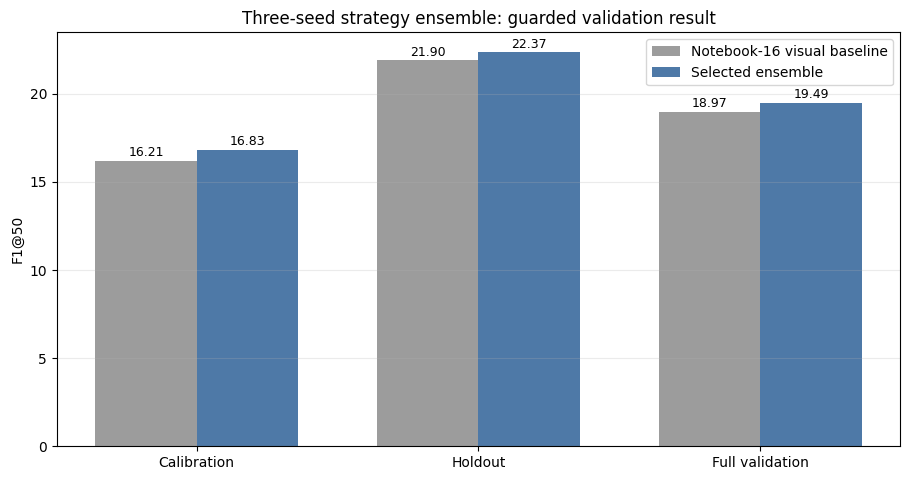

Sync final outputs to Drive:   0%|          | 0/7 [00:00<?, ?it/s]

{
  "selected_config": {
    "config_id": "n16_0.25__seed7_kd_only__mean_log_probability",
    "group": "n16_plus_seed7_kd_only",
    "member_keys": [
      "n16",
      "s7_kd"
    ],
    "method": "mean_log_probability",
    "anchor_weight": 0.25
  },
  "calibration_f1@50_gain": 0.62,
  "holdout_f1@50_gain": 0.469,
  "full_validation_f1@50_gain": 0.519,
  "promote_to_primary": true,
  "recommendation": "Promote the selected ensemble as the final validation result; it passes the predeclared calibration, holdout, full-validation, and secondary-metric rules.",
  "drive_output_root": "/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/30_three_seed_strategy_ensemble"
}


In [11]:
selected_predictions = ensemble_predict(
    selected_config["member_keys"],
    selected_config["method"],
    selected_config["anchor_weight"],
)
baseline_predictions = n16_visual_logits.argmax(axis=-1)

split_indices = {
    "calibration": calibration_indices,
    "holdout": holdout_indices,
    "full_validation": full_indices,
}
comparison_rows = []
decision_metrics = {}
for split_name, indices in split_indices.items():
    baseline_metrics = metrics_for_array(baseline_predictions, indices)
    ensemble_metrics = metrics_for_array(selected_predictions, indices)
    gains = {
        metric: float(ensemble_metrics[metric] - baseline_metrics[metric])
        for metric in metric_names
    }
    decision_metrics[split_name] = {
        "baseline": baseline_metrics,
        "selected_ensemble": ensemble_metrics,
        "gains": gains,
    }
    for method_name, metrics in [
        ("Notebook-16 visual baseline", baseline_metrics),
        ("Selected ensemble", ensemble_metrics),
    ]:
        comparison_rows.append({
            "split": split_name,
            "method": method_name,
            **metrics,
            **{
                f"{metric}_gain_vs_n16": (
                    0.0 if method_name.startswith("Notebook-16") else gains[metric]
                )
                for metric in metric_names
            },
        })

comparison_df = pd.DataFrame(comparison_rows)
COMPARISON_CSV = OUT_ROOT / "validation_ensemble_comparison.csv"
comparison_df.to_csv(COMPARISON_CSV, index=False)
display(comparison_df.round(3))

required_f1_splits = ["calibration", "holdout", "full_validation"]
f1_pass = all(
    decision_metrics[split]["gains"]["f1@50"] >= MIN_REQUIRED_F1_50_GAIN
    for split in required_f1_splits
)
secondary_pass = all(
    decision_metrics[split]["gains"]["f1@25"] >= -MAX_ALLOWED_F1_25_DROP
    and decision_metrics[split]["gains"]["edit"] >= -MAX_ALLOWED_EDIT_DROP
    for split in ["holdout", "full_validation"]
)
promote_to_primary = bool(f1_pass and secondary_pass)

if promote_to_primary:
    recommendation = (
        "Promote the selected ensemble as the final validation result; it passes the "
        "predeclared calibration, holdout, full-validation, and secondary-metric rules."
    )
else:
    recommendation = (
        "Do not promote the ensemble. Report it as the final exploratory experiment "
        "and retain the previous primary model. Do not tune another configuration on "
        "this holdout split."
    )

PREDICTIONS_NPZ = OUT_ROOT / "selected_ensemble_validation_predictions.npz"
np.savez_compressed(
    PREDICTIONS_NPZ,
    sequence_ids=np.asarray(val_ids, dtype="U"),
    targets=targets_array,
    predictions=selected_predictions,
)

plot_df = comparison_df.pivot(
    index="split", columns="method", values="f1@50"
).loc[["calibration", "holdout", "full_validation"]]
fig, ax = plt.subplots(figsize=(9.2, 4.9))
x = np.arange(len(plot_df.index))
width = 0.36
baseline_values = plot_df["Notebook-16 visual baseline"].to_numpy()
ensemble_values = plot_df["Selected ensemble"].to_numpy()
bars_a = ax.bar(
    x - width / 2, baseline_values, width,
    label="Notebook-16 visual baseline", color="#9C9C9C"
)
bars_b = ax.bar(
    x + width / 2, ensemble_values, width,
    label="Selected ensemble", color="#4E79A7"
)
ax.set_xticks(x, ["Calibration", "Holdout", "Full validation"])
ax.set_ylabel("F1@50")
ax.set_title("Three-seed strategy ensemble: guarded validation result")
ax.grid(axis="y", alpha=0.25)
ax.legend()
for bars in [bars_a, bars_b]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.08,
            f"{bar.get_height():.2f}",
            ha="center", va="bottom", fontsize=9,
        )
fig.tight_layout()
F1_PLOT = ARTIFACT_ROOT / "ensemble_f1_at_50_guarded_validation.png"
fig.savefig(F1_PLOT, dpi=180, bbox_inches="tight")
plt.show()

FINAL_SUMMARY = OUT_ROOT / "final_summary.json"
final_summary = {
    "status": "completed",
    "experiment": "assembly101_three_seed_multi_strategy_ensemble",
    "primary_metric": "F1@50",
    "selected_config": selected_config,
    "selection_protocol": {
        "configuration_selection_split": "deterministic 50% validation calibration split",
        "one_shot_evaluation_split": "remaining 50% validation holdout split",
        "split_hash_key": f"notebook28:{SEED}:<sequence_id>",
        "near_best_f1_window": NEAR_BEST_CALIBRATION_F1,
        "tie_breakers": ["F1@25", "Edit", "F1@50", "smaller ensemble"],
        "test_split_read": False,
    },
    "checkpoint_reconstruction_audit_pass": True,
    "decision_metrics": decision_metrics,
    "promotion_rule": {
        "minimum_f1@50_gain_on_calibration_holdout_full": MIN_REQUIRED_F1_50_GAIN,
        "maximum_f1@25_drop_on_holdout_and_full": MAX_ALLOWED_F1_25_DROP,
        "maximum_edit_drop_on_holdout_and_full": MAX_ALLOWED_EDIT_DROP,
    },
    "promote_to_primary": promote_to_primary,
    "recommendation": recommendation,
    "limitations": [
        "Base checkpoints were originally selected on the full validation set; the holdout is independent only of ensemble composition selection.",
        "The experiment evaluates three student seeds and one notebook-16 baseline seed.",
        "No test-set claim is made in notebook 30.",
        "The temporal representation contains only 16 positions per sequence.",
    ],
    "paths": {
        "individual_model_audit": str(INDIVIDUAL_AUDIT_CSV),
        "calibration_search": str(SEARCH_CSV),
        "validation_comparison": str(COMPARISON_CSV),
        "selected_predictions": str(PREDICTIONS_NPZ),
        "f1@50_plot": str(F1_PLOT),
        "student_logits": str(CONSOLIDATED_CACHE),
    },
    "created_utc": datetime.now(timezone.utc).isoformat(),
}
FINAL_SUMMARY.write_text(json.dumps(final_summary, indent=2), encoding="utf-8")

# Persist compact results and the consolidated cache. Per-model caches were already
# synced immediately after each inference pass.
for local_path in tqdm(
    [
        CONSOLIDATED_CACHE,
        INDIVIDUAL_AUDIT_CSV,
        SEARCH_CSV,
        COMPARISON_CSV,
        PREDICTIONS_NPZ,
        F1_PLOT,
        FINAL_SUMMARY,
    ],
    desc="Sync final outputs to Drive",
):
    relative = local_path.relative_to(OUT_ROOT)
    copy_with_retry(local_path, DRIVE_OUT_ROOT / relative, overwrite=True)

print(json.dumps({
    "selected_config": selected_config,
    "calibration_f1@50_gain": round(
        decision_metrics["calibration"]["gains"]["f1@50"], 3
    ),
    "holdout_f1@50_gain": round(
        decision_metrics["holdout"]["gains"]["f1@50"], 3
    ),
    "full_validation_f1@50_gain": round(
        decision_metrics["full_validation"]["gains"]["f1@50"], 3
    ),
    "promote_to_primary": promote_to_primary,
    "recommendation": recommendation,
    "drive_output_root": str(DRIVE_OUT_ROOT),
}, indent=2))
